In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vaukaofworlds/thecycloneimagedataset")
print("Path to dataset files:", path)


100%|██████████| 1.54G/1.54G [00:15<00:00, 104MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vaukaofworlds/thecycloneimagedataset/versions/3


In [5]:
import pandas as pd
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import os

class CycloneDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.data = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        intensity = self.data.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        return image, intensity


In [6]:
# ✅ 1. IMPORTS
import os
import h5py
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import timm
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ✅ 2. LOAD DATA
path = "/root/.cache/kagglehub/datasets/vaukaofworlds/thecycloneimagedataset/versions/3"
image_path = os.path.join(path, "Cyclone_Images.h5")
label_path = os.path.join(path, "Cyclone_Labels h5.npy")

with h5py.File(image_path, 'r') as f:
    images = np.array(f['Images'])

# Extract intensity only (column index 5)
raw_labels = np.load(label_path, allow_pickle=True)
intensity_labels = np.array([float(row[5]) for row in raw_labels], dtype=np.float32)

print("Images shape:", images.shape)
print("Labels shape:", intensity_labels.shape)
print("Sample intensity:", intensity_labels[0])


Images shape: (21076, 128, 128, 4)
Labels shape: (21076,)
Sample intensity: 30.0


In [7]:
class CycloneH5Dataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]

        # If shape is (C, H, W), convert to (H, W, C)
        if img.shape[0] in [3, 4]:
            img = np.transpose(img, (1, 2, 0))

        # ✅ Force conversion to RGB (drops alpha channel)
        img = np.nan_to_num(img, nan=0.0)                 # Remove NaNs
        img = np.clip(img, 0, 255).astype('uint8')        # Clamp to valid pixel range
        img = Image.fromarray(img).convert('RGB')         # Convert to RGB safely


        label = float(self.labels[idx])

        if self.transform:
            img = self.transform(img)

        return img, label



In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = CycloneH5Dataset(images, intensity_labels, transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16)


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model("vit_base_patch16_224", pretrained=True)
model.head = nn.Sequential(
    nn.Linear(model.head.in_features, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
)
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [10]:
# ✅ TRAINING LOOP
epochs = 5  # You can increase this to 20+ later
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_idx, (imgs, targets) in enumerate(train_loader):
        imgs = imgs.to(device)
        targets = targets.clone().detach().float().to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # 👇 Add this line to show it's alive
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx+1}/{len(train_loader)}")

    print(f"✅ Epoch {epoch+1}/{epochs} | Avg Train Loss: {total_loss / len(train_loader):.4f}")



Epoch 1, Batch 1/1054
Epoch 1, Batch 11/1054
Epoch 1, Batch 21/1054
Epoch 1, Batch 31/1054
Epoch 1, Batch 41/1054
Epoch 1, Batch 51/1054
Epoch 1, Batch 61/1054
Epoch 1, Batch 71/1054
Epoch 1, Batch 81/1054
Epoch 1, Batch 91/1054
Epoch 1, Batch 101/1054
Epoch 1, Batch 111/1054
Epoch 1, Batch 121/1054
Epoch 1, Batch 131/1054
Epoch 1, Batch 141/1054
Epoch 1, Batch 151/1054
Epoch 1, Batch 161/1054
Epoch 1, Batch 171/1054
Epoch 1, Batch 181/1054
Epoch 1, Batch 191/1054
Epoch 1, Batch 201/1054
Epoch 1, Batch 211/1054
Epoch 1, Batch 221/1054
Epoch 1, Batch 231/1054
Epoch 1, Batch 241/1054
Epoch 1, Batch 251/1054
Epoch 1, Batch 261/1054
Epoch 1, Batch 271/1054
Epoch 1, Batch 281/1054
Epoch 1, Batch 291/1054
Epoch 1, Batch 301/1054
Epoch 1, Batch 311/1054
Epoch 1, Batch 321/1054
Epoch 1, Batch 331/1054
Epoch 1, Batch 341/1054
Epoch 1, Batch 351/1054
Epoch 1, Batch 361/1054
Epoch 1, Batch 371/1054
Epoch 1, Batch 381/1054
Epoch 1, Batch 391/1054
Epoch 1, Batch 401/1054
Epoch 1, Batch 411/1054
Epo

In [11]:
model.eval()
true_labels, predictions = [], []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs).cpu().squeeze()
        predictions.extend(outputs.numpy())
        true_labels.extend(targets)

mae = mean_absolute_error(true_labels, predictions)
r2 = r2_score(true_labels, predictions)

print(f"📊 MAE: {mae:.2f}")
print(f"📈 R² Score: {r2:.2f}")


📊 MAE: 10.05
📈 R² Score: 0.80


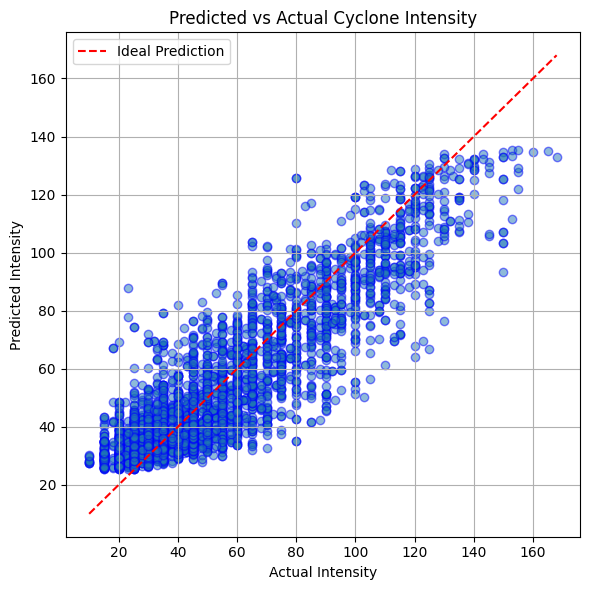

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(true_labels, predictions, alpha=0.5, edgecolors='b')
plt.plot([min(true_labels), max(true_labels)],
         [min(true_labels), max(true_labels)], 'r--', label='Ideal Prediction')
plt.xlabel("Actual Intensity")
plt.ylabel("Predicted Intensity")
plt.title("Predicted vs Actual Cyclone Intensity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("scatter_plot.png", dpi=300)
plt.show()


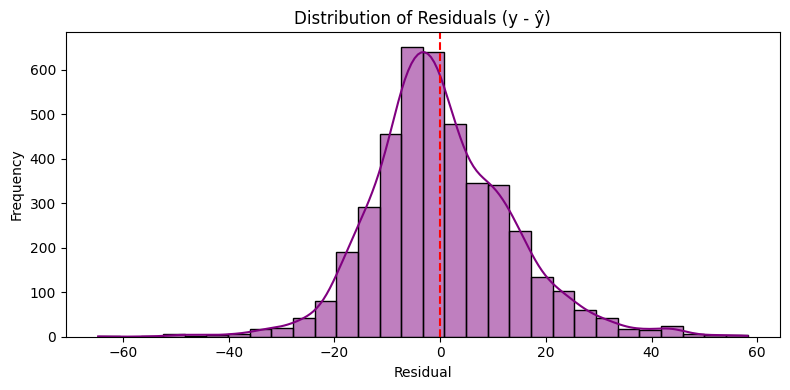

In [14]:
import seaborn as sns

residuals = np.array(true_labels) - np.array(predictions)

plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, bins=30, color="purple")
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Residuals (y - ŷ)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("residual_plot.png", dpi=300)
plt.show()


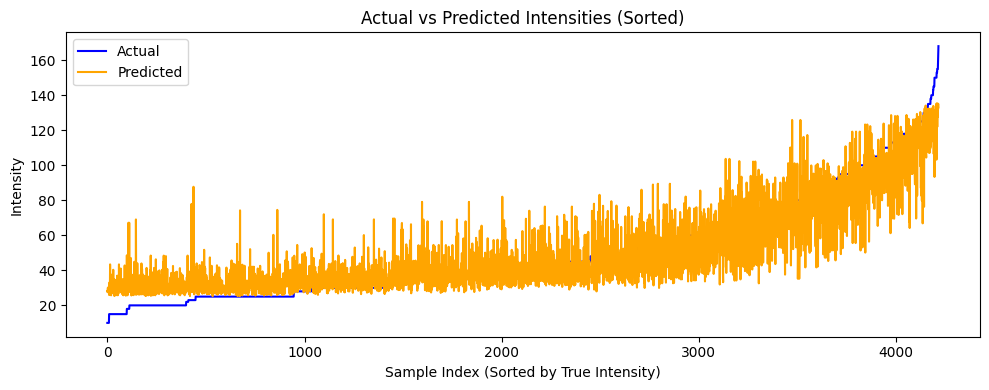

In [15]:
sorted_indices = np.argsort(true_labels)
sorted_true = np.array(true_labels)[sorted_indices]
sorted_pred = np.array(predictions)[sorted_indices]

plt.figure(figsize=(10, 4))
plt.plot(sorted_true, label="Actual", color='blue')
plt.plot(sorted_pred, label="Predicted", color='orange')
plt.title("Actual vs Predicted Intensities (Sorted)")
plt.xlabel("Sample Index (Sorted by True Intensity)")
plt.ylabel("Intensity")
plt.legend()
plt.tight_layout()
plt.savefig("line_plot.png", dpi=300)
plt.show()


/tmp/ipython-input-16-2442732965.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_per_bin = df_plot.groupby('bin')['error'].mean()


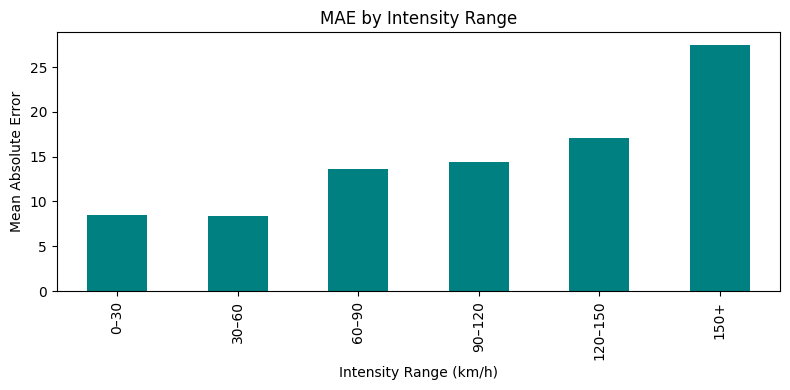

In [16]:
bins = [0, 30, 60, 90, 120, 150, 180]
labels = ['0–30', '30–60', '60–90', '90–120', '120–150', '150+']

df_plot = pd.DataFrame({'true': true_labels, 'pred': predictions})
df_plot['bin'] = pd.cut(df_plot['true'], bins=bins, labels=labels)

df_plot['error'] = abs(df_plot['true'] - df_plot['pred'])
mae_per_bin = df_plot.groupby('bin')['error'].mean()

plt.figure(figsize=(8, 4))
mae_per_bin.plot(kind='bar', color='teal')
plt.title("MAE by Intensity Range")
plt.xlabel("Intensity Range (km/h)")
plt.ylabel("Mean Absolute Error")
plt.tight_layout()
plt.savefig("mae_bins.png", dpi=300)
plt.show()

